In [1]:
"""
Teacher/Student scaling law experiment — Table 1 architecture
(Sharma & Kaplan, arXiv:2004.10802)

-Loads the trained student models and the results.npz files for each latent dimension d.
-The results.npz files contain the N_vals, L_vals, and d_intrinsic_S/T
-Computes the fitted alpha for each d using curve_fit and stores it in the alphas dictionary.
-Plots the results and saves them
"""

import numpy as np
import tensorflow as tf
from pathlib import Path
from scipy.optimize import curve_fit

# ────────────────────────────────────────────────────────────────────────
# Paths
# ────────────────────────────────────────────────────────────────────────
REPO_ROOT  = Path(".").resolve()           # assumes you run from ML-and-tameness/
MODEL_ROOT = REPO_ROOT / "models_std4_train"          # where d*/ and results.npz live

# ────────────────────────────────────────────────────────────────────────
# Power-law form (same as before)
# ────────────────────────────────────────────────────────────────────────
def power_law_with_floor(N, C0, C1, alpha):
    alpha = np.clip(alpha, -10, 10)
    return C0 + C1 * N ** (-alpha)

# ────────────────────────────────────────────────────────────────────────
# Data structures in RAM
# ────────────────────────────────────────────────────────────────────────
students = {}   # students[d][w] = loaded Keras model
alphas   = {}   # alphas[d]     = fitted alpha for that latent dimension
results  = {}   # results[d]    = dict with N_vals, L_vals, etc.

d_intrinsic_S={}
d_intrinsic_T={}

# ────────────────────────────────────────────────────────────────────────
# Load all latent-dimension folders: models/d2, models/d4, ...
# ────────────────────────────────────────────────────────────────────────
for d_dir in sorted(MODEL_ROOT.glob("d*")):
    if not d_dir.is_dir():
        continue

    # Parse d from folder name 'd4' -> 4
    try:
        d_latent = int(d_dir.name[1:])
    except ValueError:
        continue

    print(f"\n=== Loading models and data for d = {d_latent} from {d_dir} ===")

    # ────────────────────────────────────────────────────────────────────────
    # 1. Load numeric results (N, L, etc.) and recompute alpha
    # ────────────────────────────────────────────────────────────────────────
    res_path = d_dir / "results.npz"
    if not res_path.exists():
        print(f"  ⚠ No results.npz in {d_dir}, skipping.")
        continue

    data   = np.load(res_path)
    N_vals = data["N_vals"].astype(float)
    L_vals = data["L_vals"].astype(float)
    d_intrinsic_S[d_latent] = data["d_intrinsic_S"].astype(float)
    d_intrinsic_T[d_latent] = data["d_intrinsic_T"].astype(float)

    # Initial guesses (robust but simple)
    p0 = [L_vals.min() * 0.95, L_vals.max() - L_vals.min(), 1.0]

    try:
        popt, _ = curve_fit(
            power_law_with_floor, N_vals, L_vals, p0=p0,
            bounds=([0, 0, 0], [L_vals.min() * 0.99, np.inf, 10]),
            maxfev=10_000,
        )
        C0_est, C1_est, alpha_est = popt
    except RuntimeError:
        print("  ⚠ curve_fit did not converge; setting alpha = NaN.")
        C0_est, C1_est, alpha_est = np.nan, np.nan, np.nan

    alphas[d_latent] = alpha_est
    results[d_latent] = {
        "N_vals":   N_vals,         # Parameter counts
        "L_vals":   L_vals,         # Test MSE values
        "C0":       C0_est,         # Fitted C0
        "C1":       C1_est,         # Fitted C1
        "alpha":    alpha_est,      # Fitted alpha
    }

    print(f"  → alpha(d={d_latent}) = {alpha_est:.4f}")

    # ────────────────────────────────────────────────────────────────────────
    # 2. Load all student models for this d into RAM
    # ────────────────────────────────────────────────────────────────────────
    students[d_latent] = {}
    for model_path in sorted(d_dir.glob("student_w*.keras")):
        # Extract width from filename student_w{w}.keras
        # e.g. "student_w64.keras" -> w = 64
        stem = model_path.stem            # "student_w64"
        try:
            w_str = stem.split("w", 1)[1]
            width = int(w_str)
        except (IndexError, ValueError):
            print(f"  ⚠ Could not parse width from {model_path.name}, skipping.")
            continue

        print(f"  Loading model: d={d_latent}, width={width}")
        model = tf.keras.models.load_model(model_path)
        students[d_latent][width] = model

print("\n=== Done. All alphas and models are now in RAM. ===")




=== Loading models and data for d = 10 from C:\Users\Priet005\OneDrive - Universiteit Utrecht\Documents\My repo\ML and information theory\Error vs dimension\models_std4_train\d10 ===
  → alpha(d=10) = 0.7738
  Loading model: d=10, width=10
  Loading model: d=10, width=12
  Loading model: d=10, width=128
  Loading model: d=10, width=16
  Loading model: d=10, width=168
  Loading model: d=10, width=18
  Loading model: d=10, width=20
  Loading model: d=10, width=24
  Loading model: d=10, width=28
  Loading model: d=10, width=32
  Loading model: d=10, width=36
  Loading model: d=10, width=40
  Loading model: d=10, width=46
  Loading model: d=10, width=52
  Loading model: d=10, width=58
  Loading model: d=10, width=64
  Loading model: d=10, width=72
  Loading model: d=10, width=8
  Loading model: d=10, width=80
  Loading model: d=10, width=96

=== Loading models and data for d = 12 from C:\Users\Priet005\OneDrive - Universiteit Utrecht\Documents\My repo\ML and information theory\Error vs di

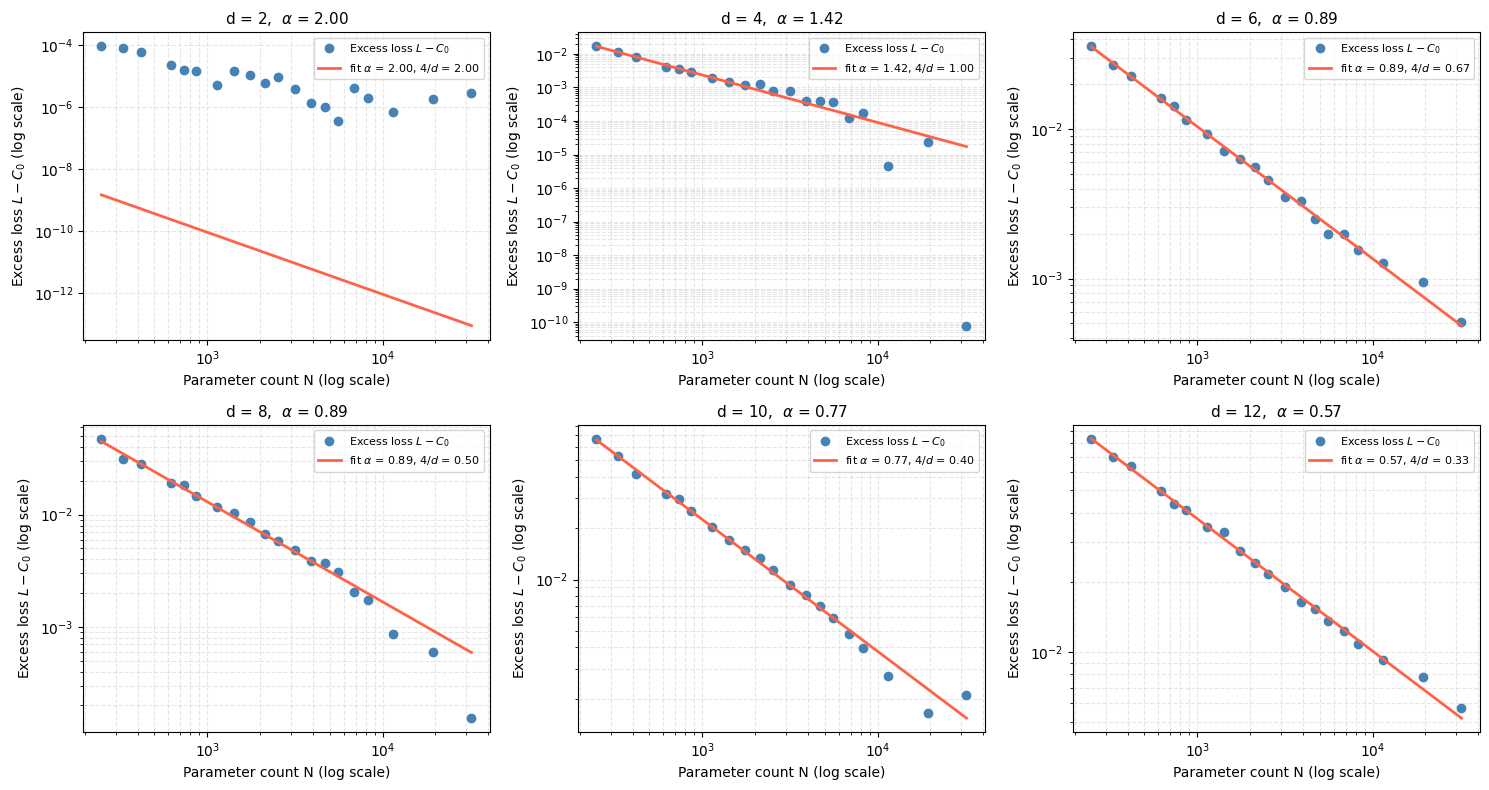

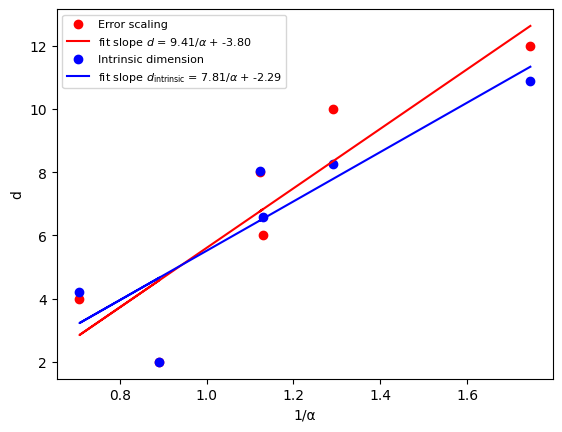

In [3]:
# ---------------------------------------------------------------------
# Curve fit to the predicted law L(N) = C0 + C1 * N^(-alpha)
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)


dims = sorted(results.keys())
n_dims = len(dims)

n_cols = min(3, n_dims)
n_rows = int(np.ceil(n_dims / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

list=[(idx, d) for idx, d in enumerate(dims) if d>=2]

for idx, d in list:
    row = idx // n_cols
    col = idx % n_cols
    ax  = axes[row][col]

    r        = results[d]
    N        = r["N_vals"]
    L        = r["L_vals"]
    alpha_th = 4.0 / d

# ── Scaling law fit ────────────────────────


    p0 = [L.min() * 0.9, L.max() - L.min(), alpha_th]  # initial guess for [C0, C1, alpha]

    try:
        popt, _ = curve_fit(
            power_law_with_floor, N, L, p0=p0,
            bounds=([0, 0, 0], [L.min() , np.inf, 10]),
            maxfev=10_000,
        )
        C0_est, C1_est, alpha_est = popt
    except RuntimeError:
        print("  ⚠  curve_fit did not converge; storing NaNs.")
        C0_est, C1_est, alpha_est = np.nan, np.nan, np.nan

# ── Plot: data and fitted line using linear-regression alpha ─

    ax.loglog(N, L-C0_est, "o", color="steelblue", ms=6,
              label="Excess loss $L - C_0$")

    N_fit  = np.linspace(N.min(), N.max(), 200)
    ex_fit = C1_est * N_fit ** (-alpha_est)
    ax.loglog(N_fit, ex_fit, "-", color="tomato", lw=2,
              label=rf"fit $\alpha$ = {alpha_est:.2f}, $4/d$ = {alpha_th:.2f}")

    ax.set_title(rf"d = {d},  $\alpha$ = {alpha_est:.2f}", fontsize=11)
    ax.set_xlabel("Parameter count N (log scale)")
    ax.set_ylabel(r"Excess loss $L - C_0$ (log scale)")
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.legend(fontsize=8, loc="best")

# Hide unused subplots
for j in range(idx + 1, n_rows * n_cols):
    row = j // n_cols
    col = j % n_cols
    axes[row][col].axis("off")

plt.tight_layout()
plt.show()

# ── Save figure 1 ──────────────────────────────
fig.savefig("output/scaling_law_fits.pdf", bbox_inches="tight")

plt.show()


# ─────────────────────────────────────────────
# Regression of d (computed with linear regression) and intrinsic dimension (computed with MLE (Levina-Bickel) intrinsic dimension estimator) vs 1/alpha
# ─────────────────────────────────────────────
dims = np.array(dims, dtype=float)
d_intrinsic_S_ref = np.array([d_intrinsic_S[d] for d in dims], dtype=float)[:,-1]

# Use the new alpha estimates from linear regression
d_alpha_list = np.array([1.0 / results[d]["alpha"] for d in dims], dtype=float)

m_d,  b_d  = np.polyfit(d_alpha_list, dims, 1)
m_ID, b_ID = np.polyfit(d_alpha_list, d_intrinsic_S_ref, 1)

dim_pred_d  = m_d  * d_alpha_list + b_d
dim_pred_ID = m_ID * d_alpha_list + b_ID

fig2 = plt.figure()
plt.scatter(d_alpha_list, dims, color="red", label="Error scaling")
plt.plot(d_alpha_list, dim_pred_d, color="red",
         label=rf"fit slope $d$ = {m_d:.2f}/$\alpha$ + {b_d:.2f}")
plt.scatter(d_alpha_list, d_intrinsic_S_ref, color="blue", label="Intrinsic dimension")
plt.plot(d_alpha_list, dim_pred_ID, color="blue",
         label=rf"fit slope $d_{{\text{{intrinsic}}}}$ = {m_ID:.2f}/$\alpha$ + {b_ID:.2f}")
plt.xlabel("1/α")
plt.ylabel("d")
plt.legend(fontsize=8, loc="best")

# ── Save figure 2 ──────────────────────────────
fig2.savefig("output/dimension_regression.pdf", bbox_inches="tight")

plt.show()

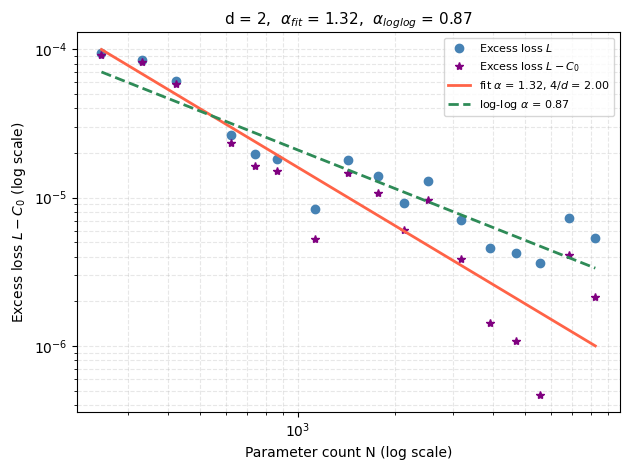

In [6]:
# ---------------------------------------------------------------------
# Case by case analysis with two different fit procedures: curve_fit and log-log linear regression
# For log-log we ignore the C0 term and fit log(L) = log(C1) - alpha * log(N), we remove the tail of the curve where the loss is very small and dominated by noise, and we compare the two estimates of alpha.
# ---------------------------------------------------------------------




d_sample = 2

interval_a = 0
interval_b = -3

r        = results[d_sample]
N        = r["N_vals"][interval_a:interval_b]
L        = r["L_vals"][interval_a:interval_b]
alpha_th = 4.0 / d_sample


       # ── Scaling law fit ────────────────────────


p0 = [r["L_vals"].min(), 1, 1]


try:
    popt, _ = curve_fit(
                power_law_with_floor, N, L, p0=p0,
                bounds=([0, 0, 0], [np.inf , np.inf, 10]),
                maxfev=10_000,
            )
    C0_est, C1_est, alpha_est = popt
except RuntimeError:
    print("  ⚠  curve_fit did not converge; storing NaNs.")
    C0_est, C1_est, alpha_est = np.nan, np.nan, np.nan


# ── Log-log linear regression estimate of alpha using L - C0 ─
excess = L
mask = excess > 0          # guard against negative/zero excess from noise
slope, intercept = np.polyfit(np.log(N[mask]), np.log(excess[mask]), 1)
alpha_loglog = -slope


# ── Plot: data and fitted line using linear-regression alpha ─
plt.loglog(N, L, "o", color="steelblue", ms=6,
            label="Excess loss $L$")
plt.loglog(N, L-C0_est, "*", color="purple", ms=6,
            label="Excess loss $L-C_0$")


N_fit  = np.linspace(N.min(), N.max(), 200)
ex_fit = C1_est * N_fit ** (-alpha_est)
plt.loglog(N_fit, ex_fit, "-", color="tomato", lw=2,
             label=rf"fit $\alpha$ = {alpha_est:.2f}, $4/d$ = {alpha_th:.2f}")

loglog_fit = np.exp(intercept) * N_fit ** (-alpha_loglog)
plt.loglog(N_fit, loglog_fit, "--", color="seagreen", lw=2,
            label=rf"log-log $\alpha$ = {alpha_loglog:.2f}")


plt.title(rf"d = {d_sample},  $\alpha_{{fit}}$ = {alpha_est:.2f},  $\alpha_{{loglog}}$ = {alpha_loglog:.2f}", fontsize=11)
plt.xlabel("Parameter count N (log scale)")
plt.ylabel(r"Excess loss $L - C_0$ (log scale)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=8, loc="best")



plt.tight_layout()
plt.show()


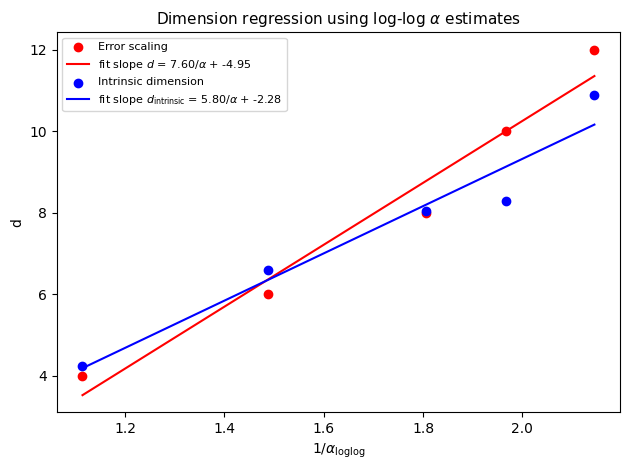

{4: np.float64(0.8973876429418741), 6: np.float64(0.6721723966574916), 8: np.float64(0.5538282866599671), 10: np.float64(0.5082410580888935), 12: np.float64(0.46619097015023103)}


In [ ]:
# ---------------------------------------------------------------------
# Compute log-log alpha for each d, then regress
# d (linear regression target) and intrinsic dimension (MLE Levina-Bickel)
# against 1/alpha_loglog
# We remove the d=2 case, because there the C0 term is very significant. In this case, the learning routine rapidly reaches the bayesian error for many of the widths, and hence the log-log fit with no C0 is not reliable.
# ---------------------------------------------------------------------


interval_a = 0
interval_b = -3   # same tail-trimming as your single-case analysis

dims = sorted(results.keys())
dims=dims[1:]

alpha_loglog_dict = {}

for d in dims:
    r = results[d]
    N = r["N_vals"][interval_a:interval_b]
    L = r["L_vals"][interval_a:interval_b]

    excess = L  # C0 ignored, as in your log-log procedure
    mask = excess > 0  # guard against negative/zero excess from noise

    slope, intercept = np.polyfit(np.log(N[mask]), np.log(excess[mask]), 1)
    alpha_loglog_dict[d] = -slope

# ── Build arrays for regression ────────────────
dims_arr = np.array(dims, dtype=float)
d_intrinsic_S_ref = np.array([d_intrinsic_S[d] for d in dims], dtype=float)[:, -1]

d_alpha_loglog_list = np.array([1.0 / alpha_loglog_dict[d] for d in dims], dtype=float)

m_d,  b_d  = np.polyfit(d_alpha_loglog_list, dims_arr, 1)
m_ID, b_ID = np.polyfit(d_alpha_loglog_list, d_intrinsic_S_ref, 1)

dim_pred_d  = m_d  * d_alpha_loglog_list + b_d
dim_pred_ID = m_ID * d_alpha_loglog_list + b_ID

# ── Plot ────────────────────────────────────────
fig3 = plt.figure()

plt.scatter(d_alpha_loglog_list, dims_arr, color="red", label="Error scaling")
plt.plot(d_alpha_loglog_list, dim_pred_d, color="red",
         label=rf"fit slope $d$ = {m_d:.2f}/$\alpha$ + {b_d:.2f}")

plt.scatter(d_alpha_loglog_list, d_intrinsic_S_ref, color="blue", label="Intrinsic dimension")
plt.plot(d_alpha_loglog_list, dim_pred_ID, color="blue",
         label=rf"fit slope $d_{{\text{{intrinsic}}}}$ = {m_ID:.2f}/$\alpha$ + {b_ID:.2f}")

plt.xlabel(r"$1/\alpha_{\text{loglog}}$")
plt.ylabel("d")
plt.title("Dimension regression using log-log $\\alpha$ estimates", fontsize=11)
plt.legend(fontsize=8, loc="best")
plt.tight_layout()

# ── Save figure ──────────────────────────────────
fig3.savefig("output/dimension_regression_loglog_alpha.png", dpi=300, bbox_inches="tight")
fig3.savefig("output/dimension_regression_loglog_alpha.pdf", bbox_inches="tight")

plt.show()

print(alpha_loglog_dict)


#We observe that the plot using the log-log estimates and the intrinsic dimension gets close to the expected coefficient alpha=4.
#A longer trainging time and an improved fitting method to deal with the bayesian error will likely improve the results.